<a href="https://colab.research.google.com/github/rashmikanaujiya1701/RFM_Segmentation_Retention_Strategy/blob/main/02_RFM_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02_RFM_Segmentation

**Name:** Rashmi Kanaujiya

**Student ID:** (iitp_aiml_25061009)  
**Course:** Trimester 3 Project  
**Dataset:** d2c churn data package

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import timedelta

pd.set_option('display.max_columns', None)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
base_path = "/content/drive/MyDrive/T3_Project_Rashmi_Kanaujiya"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Dataset

In [ ]:
orders = pd.read_csv('/content/drive/MyDrive/T3_Project_Rashmi_Kanaujiya/D2C_Customer_Churn_Intelligence/Notebooks/RFM_Segmentation_Retention_Strategy/data/orders.csv')
tickets = pd.read_csv('/content/drive/MyDrive/T3_Project_Rashmi_Kanaujiya/D2C_Customer_Churn_Intelligence/Notebooks/RFM_Segmentation_Retention_Strategy/data/support_tickets.csv')
events = pd.read_csv('/content/drive/MyDrive/T3_Project_Rashmi_Kanaujiya/D2C_Customer_Churn_Intelligence/Notebooks/RFM_Segmentation_Retention_Strategy/data/web_events_snapshot.csv')
churn = pd.read_csv('/content/drive/MyDrive/T3_Project_Rashmi_Kanaujiya/D2C_Customer_Churn_Intelligence/Notebooks/RFM_Segmentation_Retention_Strategy/data/churn_labels.csv')
campaigns = pd.read_csv('/content/drive/MyDrive/T3_Project_Rashmi_Kanaujiya/D2C_Customer_Churn_Intelligence/Notebooks/RFM_Segmentation_Retention_Strategy/data/intervention_history.csv')
support = pd.read_csv('/content/drive/MyDrive/T3_Project_Rashmi_Kanaujiya/D2C_Customer_Churn_Intelligence/Notebooks/RFM_Segmentation_Retention_Strategy/data/support_tickets.csv')
snapshot = pd.read_csv('/content/drive/MyDrive/T3_Project_Rashmi_Kanaujiya/D2C_Customer_Churn_Intelligence/Notebooks/RFM_Segmentation_Retention_Strategy/data/rfm_modeling_snapshot.csv')

## Dataset Overview

In [ ]:
print("Orders Shape:", orders.shape)
print("Support Shape:", support.shape)
print("Web Shape:", events.shape)
print("Campaign Shape:", campaigns.shape)
print("Snapshot Shape:", snapshot.shape)

Orders Shape: (10009, 10)
Support Shape: (1921, 8)
Web Shape: (2400, 10)
Campaign Shape: (2400, 5)
Snapshot Shape: (2400, 29)


In [ ]:
orders.head()

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0
3,ORD000005,CUST00001,2025-01-22,Hair Care,1,433.15,0.27,2,0,4.0
4,ORD000004,CUST00001,2025-02-28,Skin Care,1,569.22,0.34,4,0,4.0


In [ ]:
support.head()

,ticket_id,customer_id,ticket_date,issue_type,support_channel,resolution_hours,sentiment_score,reopened
0,TKT000001,CUST00001,2024-10-28,damaged_item,chat,3.9,-0.16,0
1,TKT000002,CUST00001,2025-02-03,payment_issue,chat,4.8,0.44,0
2,TKT000003,CUST00002,2025-08-30,late_delivery,chat,1.0,0.00,0
3,TKT000004,CUST00005,2025-05-02,late_delivery,call,37.7,-1.00,0
4,TKT000005,CUST00006,2025-08-13,general_query,call,23.1,-0.68,1


## Data Cleaning

In [ ]:
orders.drop_duplicates(inplace=True)

support.drop_duplicates(inplace=True)

events.drop_duplicates(inplace=True)

campaigns.drop_duplicates(inplace=True)

In [ ]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_date,0
category,0
quantity,0
gross_amount,0
discount_pct,0
delivery_days,0
returned,0
rating,80


## RFM Feature Creation

In [ ]:
orders['order_date'] = pd.to_datetime(
    orders['order_date']
)

In [ ]:
snapshot_date = orders['order_date'].max() + timedelta(days=1)

In [ ]:
rfm = orders.groupby('customer_id').agg({

'order_date':
lambda x:(snapshot_date-x.max()).days,

'order_id':'nunique',

'gross_amount':'sum'

}).reset_index()

rfm.columns = [
'customer_id',
'recency',
'frequency',
'monetary'
]

In [ ]:
rfm.head()

,customer_id,recency,frequency,monetary
0,CUST00001,168,6,2955.57
1,CUST00002,35,3,1713.10
2,CUST00003,232,1,649.98
3,CUST00004,192,1,1604.04
4,CUST00005,11,6,3910.43


Create RFM Scores

In [ ]:
rfm['R'] = pd.qcut(
    rfm['recency'],
    5,
    labels=[5,4,3,2,1]
)

rfm['F'] = pd.qcut(
    rfm['frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

rfm['M'] = pd.qcut(
    rfm['monetary'],
    5,
    labels=[1,2,3,4,5]
)

In [ ]:
rfm['RFM_Score'] = (
    rfm['R'].astype(str)
    + rfm['F'].astype(str)
    + rfm['M'].astype(str)
)

### RFM Score Distribution

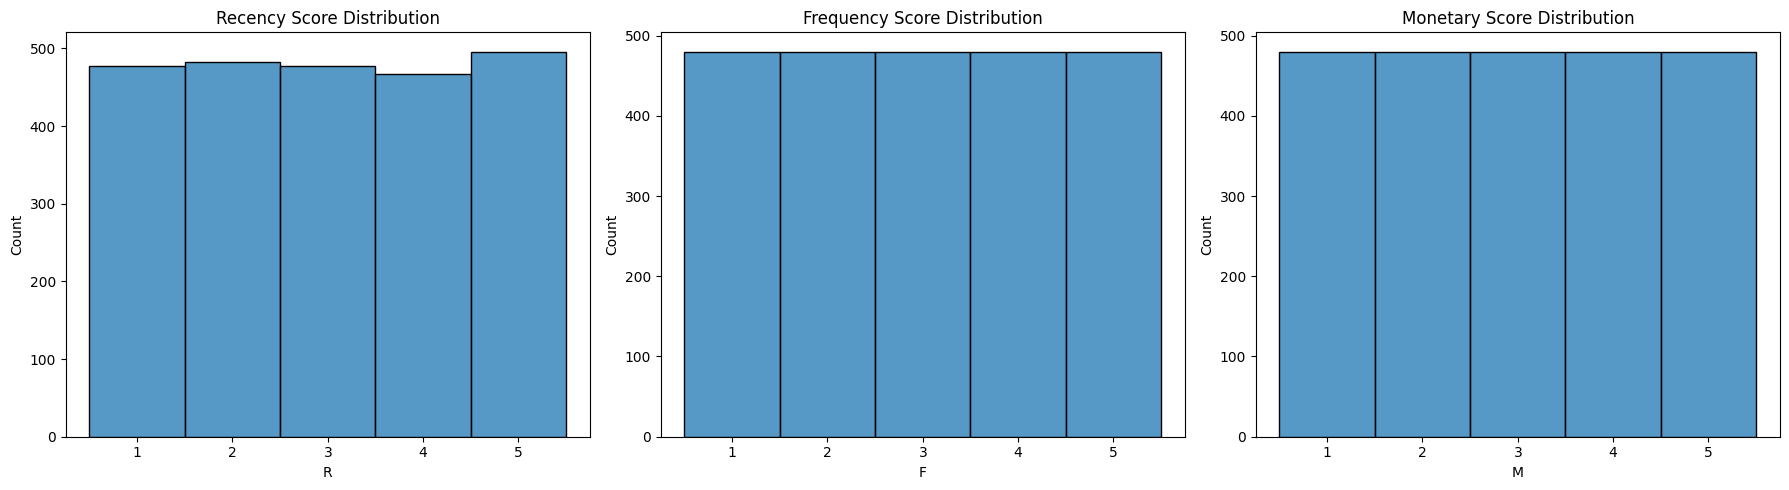

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm['R'], bins=5, ax=axes[0], discrete=True)
axes[0].set_title('Recency Score Distribution')
axes[0].set_xticks([1, 2, 3, 4, 5])

sns.histplot(rfm['F'], bins=5, ax=axes[1], discrete=True)
axes[1].set_title('Frequency Score Distribution')
axes[1].set_xticks([1, 2, 3, 4, 5])

sns.histplot(rfm['M'], bins=5, ax=axes[2], discrete=True)
axes[2].set_title('Monetary Score Distribution')
axes[2].set_xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.savefig(os.path.join(output_path, 'rfm_distribution.png'))
plt.show()

## Additional Signal 1 – Support Complaints

In [ ]:
support_features = support.groupby(
'customer_id'
).agg(

support_ticket_count=
('ticket_id','count')

).reset_index()

## Additional Signal 2 – Web Engagement

In [ ]:
events_features = events.groupby(
'customer_id'
).agg(

sessions_30d=
('sessions_30d','mean'),

product_views_30d=
('product_views_30d','mean'),

campaign_clicks_30d=
('campaign_clicks_30d','mean')

).reset_index()

## Additional Signal 3 – Campaign Engagement

In [ ]:
campaigns_features = campaigns.groupby(
'customer_id'
).agg(

campaigns_count=
('last_campaign_received','count')

).reset_index()

Merge Features

In [ ]:
segments = rfm.merge(
support_features,
on='customer_id',
how='left'
)

segments = segments.merge(
events_features,
on='customer_id',
how='left'
)

segments = segments.merge(
campaigns_features,
on='customer_id',
how='left'
)


segments['R'] = segments['R'].astype(int)
segments['F'] = segments['F'].astype(int)
segments['M'] = segments['M'].astype(int)

segments.fillna(0,inplace=True)

Segment Logic

In [ ]:
def assign_segment(row):

    if (
        row['R'] >= 4 and
        row['F'] >= 4 and
        row['M'] >= 4
    ):
        return 'Champions'

    elif (
        row['F'] >= 4
    ):
        return 'Loyal Customers'

    elif (
        row['M'] >= 4 and
        row['R'] <= 2
    ):
        return 'At Risk High Value'

    elif (
        row['support_ticket_count'] >= 3
    ):
        return 'High Value But Unhappy'

    elif (
        row['sessions_30d'] <= 2
    ):
        return 'Dormant Customers'

    else:
        return 'New Customers'

In [ ]:
segments['segment_name'] = segments.apply(
assign_segment,
axis=1
)

Segment Distribution

In [ ]:
segments['segment_name'].value_counts()

,count
segment_name,
New Customers,875
Loyal Customers,520
Dormant Customers,487
Champions,440
At Risk High Value,67
High Value But Unhappy,11


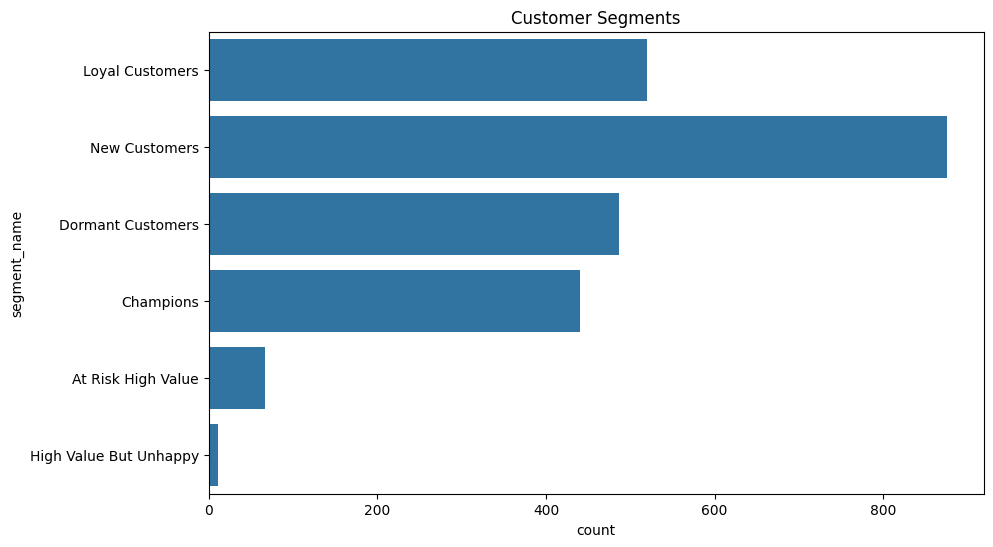

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
y='segment_name',
data=segments
)

plt.title("Customer Segments")

plt.show()

In [ ]:
output_path = os.path.join(base_path, "D2C_Customer_Churn_Intelligence", "Notebooks", "RFM_Segmentation_Retention_Strategy", "outputs")
# Create the directory if it doesn't exist
os.makedirs(output_path, exist_ok=True)

plt.savefig(os.path.join(output_path, 'customer_segments.png'))

<Figure size 640x480 with 0 Axes>

Segment Summary

In [ ]:
segment_summary = segments.groupby(
'segment_name'
).agg({

'recency':'mean',
'frequency':'mean',
'monetary':'mean',
'support_ticket_count':'mean'

}).round(2)

segment_summary

,recency,frequency,monetary,support_ticket_count
segment_name,,,,
At Risk High Value,226.43,3.55,4312.69,0.88
Champions,19.90,7.35,5679.80,1.31
Dormant Customers,170.54,2.26,1626.33,0.47
High Value But Unhappy,135.00,3.55,2497.18,3.00
Loyal Customers,117.56,6.32,4502.69,1.29
New Customers,98.44,2.41,1710.55,0.40


### Revenue by Segment

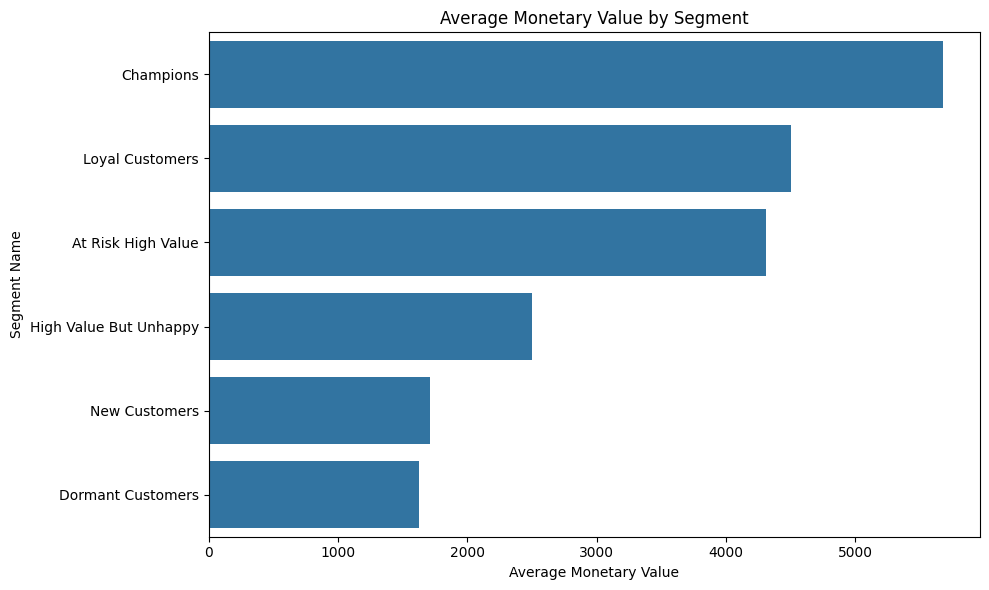

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='monetary', y='segment_name', data=segment_summary.reset_index().sort_values(by='monetary', ascending=False))
plt.title('Average Monetary Value by Segment')
plt.xlabel('Average Monetary Value')
plt.ylabel('Segment Name')
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'revenue_by_segment.png'))
plt.show()

### Support Tickets by Segment

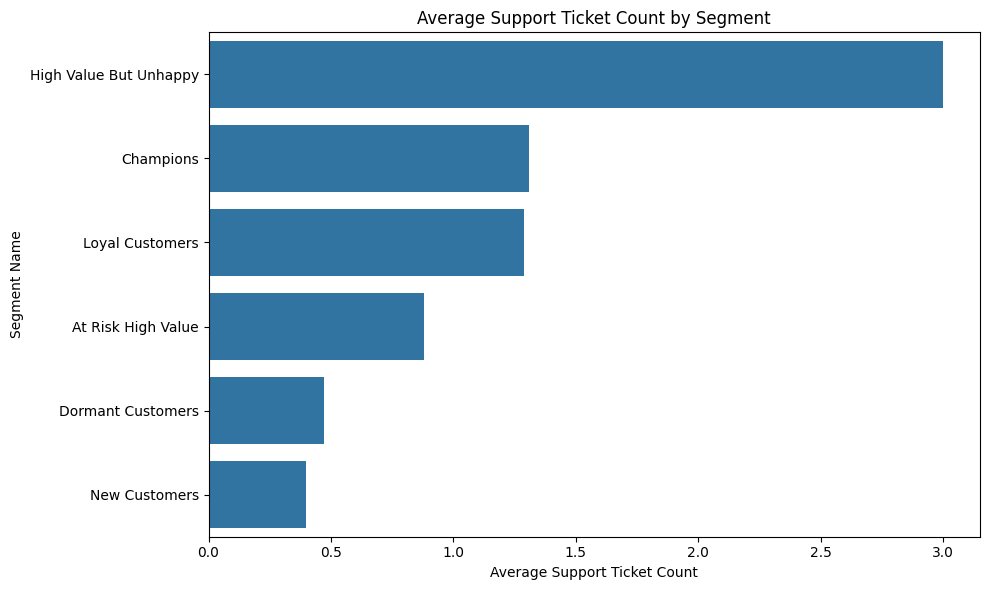

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='support_ticket_count', y='segment_name', data=segment_summary.reset_index().sort_values(by='support_ticket_count', ascending=False))
plt.title('Average Support Ticket Count by Segment')
plt.xlabel('Average Support Ticket Count')
plt.ylabel('Segment Name')
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'support_vs_segment.png'))
plt.show()

Retention Strategy Table

In [ ]:
retention_strategy = pd.DataFrame({

'Segment':[
'Champions',
'Loyal Customers',
'At Risk High Value',
'High Value But Unhappy',
'Dormant Customers',
'New Customers'
],

'Retention Action':[

'VIP Rewards & Early Access',

'Loyalty Program Upgrade',

'Personalized Win-back Offer',

'Dedicated Support Recovery Campaign',

'Reactivation Email Campaign',

'Welcome Journey Campaign'

]

})

retention_strategy

,Segment,Retention Action
0,Champions,VIP Rewards & Early Access
1,Loyal Customers,Loyalty Program Upgrade
2,At Risk High Value,Personalized Win-back Offer
3,High Value But Unhappy,Dedicated Support Recovery Campaign
4,Dormant Customers,Reactivation Email Campaign
5,New Customers,Welcome Journey Campaign


### Campaign Budget Prioritization
Assume budget ₹100,000

In [ ]:
budget = pd.DataFrame({

'Segment':[
'At Risk High Value',
'High Value But Unhappy',
'Loyal Customers',
'Dormant Customers',
'Champions',
'New Customers'
],

'Budget_Allocated':[
40000,
25000,
15000,
10000,
5000,
5000
]

})

budget

,Segment,Budget_Allocated
0,At Risk High Value,40000
1,High Value But Unhappy,25000
2,Loyal Customers,15000
3,Dormant Customers,10000
4,Champions,5000
5,New Customers,5000


Priority Order

In [ ]:
budget.sort_values(
'Budget_Allocated',
ascending=False
)

,Segment,Budget_Allocated
0,At Risk High Value,40000
1,High Value But Unhappy,25000
2,Loyal Customers,15000
3,Dormant Customers,10000
4,Champions,5000
5,New Customers,5000


### Retention Budget Priority

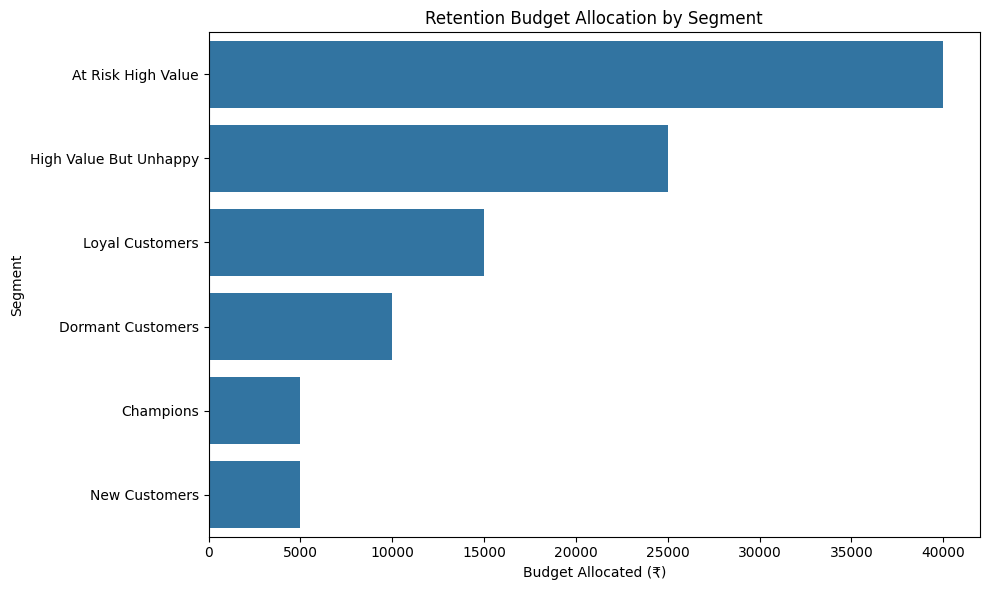

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Budget_Allocated', y='Segment', data=budget.sort_values(by='Budget_Allocated', ascending=False))
plt.title('Retention Budget Allocation by Segment')
plt.xlabel('Budget Allocated (₹)')
plt.ylabel('Segment')
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'retention_priority.png'))
plt.show()

### Manual Review Cases

Select 10 difficult customers

In [ ]:
manual_review = segments[

(
segments['monetary']
>
segments['monetary'].quantile(.75)
)

&

(
segments['support_ticket_count']
>=2
)

].head(10)

Create segments

In [ ]:
import os

segments.to_csv(
    os.path.join(base_path, "D2C_Customer_Churn_Intelligence", "Notebooks","RFM_Segmentation_Retention_Strategy", "segments.csv"),
    index=False
)

Create retention_strategy.md

In [ ]:
import os

with open(os.path.join(base_path, "D2C_Customer_Churn_Intelligence", "Notebooks","RFM_Segmentation_Retention_Strategy", "retention_strategy.md"),"w") as f:
    f.write(strategy_text)

In [ ]:
strategy_text = """

# Retention Strategy

## Champions
VIP rewards and exclusive launches

## Loyal Customers
Loyalty program incentives

## At Risk High Value
Highest retention priority

## High Value But Unhappy
Service recovery intervention

## Dormant Customers
Win-back campaign

## New Customers
Onboarding campaign

# Budget Priority

1. At Risk High Value
2. High Value But Unhappy
3. Loyal Customers
4. Dormant Customers
5. Champions
6. New Customers

"""

with open(
'retention_strategy.md',
'w'
) as f:

    f.write(strategy_text)


Create manual_review_cases.md

In [ ]:
import os
with open(os.path.join(base_path, "D2C_Customer_Churn_Intelligence", "Notebooks","RFM_Segmentation_Retention_Strategy", "manual_review_cases.md"),"w") as f:
    f.write(strategy_text)

In [ ]:
with open(
'manual_review_cases.md',
'w'
) as f:

    f.write(
        manual_review.to_markdown(
            index=False
        )
    )

Create requirements.txt

In [ ]:
readme = """

# Part 2 - RFM Segmentation & Retention Strategy

## Objective

Build customer segments using:

- Recency
- Frequency
- Monetary Value

Additional signals:

- Support Complaints
- Web Activity
- Campaign Engagement

## Segments

1. Champions
2. Loyal Customers
3. At Risk High Value
4. High Value But Unhappy
5. Dormant Customers
6. New Customers

## Outputs

- rfm_segmentation.ipynb
- segments.csv
- retention_strategy.md
- manual_review_cases.md
- requirements.txt

"""

with open(
'README.md',
'w'
) as f:

    f.write(readme)

# Summary: RFM Segmentation & Retention Strategy

This project helps a D2C personal-care company identify which customers should receive retention attention before deploying a machine learning model. The analysis is based on RFM (Recency, Frequency, Monetary) segmentation combined with additional customer behavior signals.

Objectives
Analyze customer purchasing behavior using RFM metrics.
Create meaningful customer segments.
Identify customers at risk of churn.
Recommend targeted retention strategies.
Prioritize retention campaigns under a limited budget.
Review ambiguous customer cases manually for better business decisions.
Data Used
orders.csv → Purchase history for RFM calculation.
support_tickets.csv → Customer complaints/support interactions.
web_events_snapshot.csv → Customer engagement and website activity.
intervention_history.csv → Campaign and retention interaction history.
rfm_modeling_snapshot.csv → Additional customer-level features.
Features Created
RFM Features
Recency: Days since last purchase.
Frequency: Number of orders.
Monetary Value: Total spending.
Additional Signals
Support ticket count.
Website/app engagement.
Campaign participation.
Customer Segments
Champions - Recent, frequent, high-value customers.
Loyal Customers - Frequent purchasers with strong engagement.
At Risk High Value - High spenders who have not purchased recently.
High Value But Unhappy - Valuable customers with multiple complaints.
Dormant Customers - Low activity and low engagement.
New Customers - Recently acquired customers with limited purchase history.
Retention Strategy
Champions: VIP rewards, exclusive launches.
Loyal Customers: Loyalty program upgrades and referrals.
At Risk High Value: Personalized win-back campaigns.
High Value But Unhappy: Service recovery and dedicated support.
Dormant Customers: Reactivation campaigns and special offers.
New Customers: Welcome journeys and onboarding incentives.
Budget Prioritization

Retention budget is allocated to maximize revenue impact:

At Risk High Value Customers
High Value But Unhappy Customers
Loyal Customers
Dormant Customers
Champions
New Customers
Deliverables
rfm_segmentation.ipynb -Complete segmentation analysis notebook.
segments.csv - Customer-level segment assignments and features.
retention_strategy.md - Segment-wise retention recommendations.
manual_review_cases.md - Analysis of 10 complex customer cases.
README.md - Project overview and execution instructions.
requirements.txt - Required Python libraries.
Business Impact

The project enables the company to focus retention efforts on customers with the highest revenue risk, improve marketing efficiency, reduce churn, and increase customer lifetime value through targeted interventions.